In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text", "text": f"""
Objective:
Analyze the given image and extract visually distinctive attributes for objects belonging to the following categories:
{tags}

Attribute Guidelines (List only clearly visible and most distinctive attributes, in order of priority):

1. Object type/subcategory (e.g., smartphone, hardcover book)
2. Appearance (shape/size/notable features)
3. Material/texture (e.g., glossy, matte, fabric)
4. Components (attached parts, e.g., strap on handbag)
5. Color scheme (dominant colors/patterns)
6. Interaction Status (usage mode, e.g., held, open)
7. Surface text/graphics (visible logos/labels)
8. Spatial location (approximate position in the frame)
9. Adjacent objects (only include core objects with stable positional relationships)

Rules:
- Only include categories that are present in the image.
- List only attributes that are visually confirmed. Do not guess or assume.
- For multiple instances of the same category, describe the most prominent or clearly visible one.
- Limit each object's attributes to a maximum of 10.
- Do not describe the absence of something (e.g., "no visible label" should not be included unless it's a critical identifying feature).
- Select the most significant visual features from the 9 attribute categories, prioritizing those with high visual distinctiveness over those with low category relevance. A single attribute in the description may correspond to multiple attribute categories if it is visually prominent.
- Organize the output in a structured format, suitable for inclusion in a JSON string.

Example Outputs:
[Suitcase]: ["hardshell"], ["navy blue"], ["on airport cart"], ["rectangular"], ["scratches"], ["wheeled"], ["with retractable handle"]
[Laptop]: ["gaming laptop"], ["RGB keyboard"], ["half-open"], ["next to mousepad"], ["'GTX' sticker on lid"]
"""}
        ]
    }
]

## 0、准备

In [1]:

import os
import torch

from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

model_path = "/root/models/Qwen2.5-VL-7B-Instruct/" #"Qwen/Qwen2.5-VL-7B-Instruct"
assert os.path.exists(model_path)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="flash_attention_2",
)

#模型中每幅图像的视觉标记数量的默认范围为 4-16384。
#您可以根据需要设置 min_pixels 和 max_pixels，例如 256-1280 的 token 范围，以平衡性能和显存占用
processor = AutoProcessor.from_pretrained(
    model_path,
    # min_pixels=256*28*28, max_pixels=1280*28*28,
)

print('\n模型加载完毕！')

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]


模型加载完毕！


## 1、基本

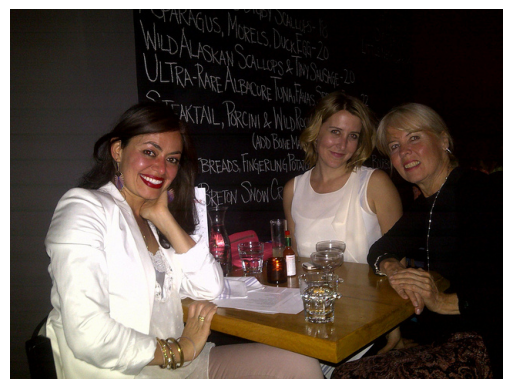

/root/miniconda3/lib/python3.12/site-packages/torch/nn/modules/conv.py:605: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv3d(



回答：
 ['[Bottle]: [dark-colored bottle with label (0.8)], [placed on table (0.7)], [likely containing beverage (0.5)], [curved neck (0.4)], [matte finish (0.3)]']


In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_path = "/root/autodl-fs/demo/grounding_data/coco/train2017/000000272026.jpg"
# 展示图片
img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                # 图片可以是 URL、本地图片路径、base64编码（data:image;base64......）
                "image": img_path,
            },
            {"type": "text", "text": """
Objective:
Analyze images and extract visually distinctive attributes for objects belonging to these categories:
[  "bottle"]

Attribute Priority (0-1 weight score, 0=exclude, 1=definitive):
Distinctive Visual Features (e.g., ribbed bottle, stemmed wine glass)
Color Scheme (dominant hues, patterns)
Spatial Position (precise frame location)
Shape & Size (notable proportions)
Material/Texture (glossy, matte, woven)
Attached Components (removable parts)
Usage Status (dynamic interactions)
Visible Text/Graphics (logos, labels)
Adjacent Objects (proximity relationships)

Rules:
Omit categories not present in the image.
Only include attributes verifiable by visual cues (no inference).
For each object in the category list, must output attributes ()
For unrecognizable objects, use [Object Category]: [unknown (0)] with at least 1 attribute
Each object must list at least 5 attributes (inferred attributes allowed with weight ≤0.4)

Output Format:
[Object Category]: [Attribute 1 (weight)], [Attribute 2 (weight)], ...
Examples:
**Invalid Example (Do Not Imitate):**  
[Cup]: [clear glass cup with handle (0.8), placed on table (0.7), possibly containing water or another liquid ( 

**Valid Example:**  
[Dog]: [golden retriever with white paws (0.9)], [sitting on red couch (0.7)], [wearing blue collar (0.5)], [tongue out (0.3)], [front paws on floor (0.4)], [looking at camera (0.4)]
[Car]: [metallic silver sedan (0.85)], [parked 50cm from garage door (0.7)], [tinted windows (0.4)], ["BMW" logo (0.9)], [four-door design (0.6)], [shiny hubcaps (0.5)]
[Cat]: [calico cat with black spots (0.9)], [staring at bird feeder (0.8)], [on wooden windowsill (0.6)], [pointed ears (0.4)], [bushy tail (0.5)], [paw raised (0.4)]
[Chair]: [unknown（0）]
"""},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(model.device)

# Inference: Generation of the output
generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

print('\n回答：\n', output_text)



## 2、获取json并进行推理

In [ ]:
import json
import os
 
def count_jsonl_lines(file_path):
    """计算JSONL文件的总行数"""
    with open(file_path, 'r', encoding='utf-8') as f:
        return sum(1 for _ in f)
# 读取 JSONL 文件的函数
def read_jsonl_batch(file_path, batch_size):
    """
    按批次读取 JSONL 文件
    :param file_path: JSONL 文件路径
    :param batch_size: 每批数据的大小
    :yield: 每一批数据（列表形式）
    """
    batch = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                parsed_line = json.loads(line.strip())
                batch.append(parsed_line)
                if len(batch) == batch_size:
                    yield batch
                    batch = []
            except json.JSONDecodeError:
                print(f"JSON 解析错误，已跳过该行: {line}")
        if batch:
            yield batch

# 使用 Qwen2.5 模型进行属性识别
def identify_attributes(tags, image_path):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": f"""
Objective:
Analyze images and extract visually distinctive attributes for objects belonging to these categories:
Target Categories: {tags}

Attribute Priority (0-1 weight score, 0=exclude, 1=definitive):
Distinctive Visual Features (e.g., ribbed bottle, stemmed wine glass)
Color Scheme (dominant hues, patterns)
Spatial Position (precise frame location)
Shape & Size (notable proportions)
Material/Texture (glossy, matte, woven)
Attached Components (removable parts)
Usage Status (dynamic interactions)
Visible Text/Graphics (logos, labels)
Adjacent Objects (proximity relationships)

Rules:
Omit categories not present in the image.
Only include attributes verifiable by visual cues (no inference).
For each object in the category list, must output attributes ()
For unrecognizable objects, use [Object Category]: [unknown (0)] with at least 1 attribute
Each object must list at least 5 attributes (inferred attributes allowed with weight ≤0.4)
Output Format:
[Object Category]: [Attribute 1 (weight)], [Attribute 2 (weight)], ...

Examples:
**Invalid Example (Do Not Imitate):**  
[Cup]: [clear glass cup with handle (0.8), placed on table (0.7), possibly containing water or another liquid ( 

**Valid Example:**  
[Dog]: [golden retriever with white paws (0.9)], [sitting on red couch (0.7)], [wearing blue collar (0.5)], [tongue out (0.3)], [front paws on floor (0.4)], [looking at camera (0.4)]
[Car]: [metallic silver sedan (0.85)], [parked 50cm from garage door (0.7)], [tinted windows (0.4)], ["BMW" logo (0.9)], [four-door design (0.6)], [shiny hubcaps (0.5)]
[Cat]: [calico cat with black spots (0.9)], [staring at bird feeder (0.8)], [on wooden windowsill (0.6)], [pointed ears (0.4)], [bushy tail (0.5)], [paw raised (0.4)]
[Chair]: [unknown（0）]
"""}
            ]
        }
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to(model.device)

    generated_ids = model.generate(**inputs, max_new_tokens=128)
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    return output_text[0]



"""
解析属性文本
"""
def parse_attributes(attributes_text):
    """正确解析带权重的属性列表，处理结尾格式问题"""
    attribute_dict = {}
    lines = [line.strip() for line in attributes_text.split('\n') if line.strip()]
    
    for line in lines:
        try:
            if not line.startswith('[') or ']: [' not in line:
                print(f"格式错误，跳过行: {line}")
                continue
                
            # 分割对象类别和属性列表（包含结尾处理）
            obj_part, attrs_part = line.split(']: [', 1)
            obj = obj_part[1:]  # 去掉开头的[
            
            # 关键修正：处理属性列表结尾的]
            if attrs_part.endswith(']'):
                attrs_part = attrs_part[:-1]  # 去掉结尾的]
            attrs = attrs_part.split('], [')  # 按"], ["分割属性
            
            # 解析每个属性
            parsed_attrs = []
            for attr in attrs:
                attr = attr.strip()
                if not attr:
                    continue
                    
                if '(' in attr and ')' in attr:
                    # 提取属性文本和权重
                    attr_text, weight_str = attr.rsplit('(', 1)
                    weight = float(weight_str.strip(')'))
                    parsed_attrs.append({
                        "text": attr_text.strip(),
                        "weight": weight
                    })
                else:
                    parsed_attrs.append({
                        "text": attr,
                        "weight": 0.0
                    })
            
            if parsed_attrs:
                attribute_dict[obj] = parsed_attrs
                print(f"成功解析 {obj}，属性数: {len(parsed_attrs)}")
            else:
                print(f"警告: {obj} 无有效属性")
                
        except Exception as e:
            print(f"解析错误 [{line}]: {str(e)}")
            continue
            
    return attribute_dict


# if __name__ == '__main__':
#      str=" ['[Sky]: [overcast], [gray], [covering the top half of the image], [cloudy], [uniformly gray], [no distinct features], [no visible stars or sun]\n[People]: [small figures], [standing near vehicles], [distant], [human-like shapes], [clothing], [moving], [near kites]\n[Pavement]: [dirt road], [brown], [in foreground], [straight], [rough texture], [no markings], [adjacent to sand]\n[Sand]: [beach], [brown], [extending from foreground to background], [flat], [']"
#      temp=parse_attributes(str)
#      print(temp)


# 更新 JSONL 文件，添加 attributes 字段
def update_jsonl_batch(data, image_base_path, output_file_path):
    with open(output_file_path, 'a', encoding='utf-8') as f:
        for item in data:
            filename = item['filename']
            image_path = f"{image_base_path}/{filename}"
            
            for region in item['grounding']['regions']:
                phrase = region['phrase']
                attributes_text = identify_attributes(phrase, image_path)
                attribute_dict = parse_attributes(attributes_text)
                print(attributes_text)
                region['attributes'] = attribute_dict
         
            
            print(item)
            f.write(json.dumps(item) + '\n')

def main():
    file_path = '/root/autodl-fs/demo/grounding_data/coco/annotations/instances_train2017_vg_merged6.jsonl'
    image_base_path = '/root/autodl-fs/demo/grounding_data/coco/train2017'
    output_file_path = '/root/autodl-fs/demo/grounding_data/coco/annotations/instances_train2017_vg_merged6_with_attributes.jsonl'
    
    # 计算总标注数
    total_annotations = count_jsonl_lines(file_path)
    print(f"总标注数: {total_annotations}")
    
    batch_size = 100
    processed_count = 0
    
    # 清空或创建输出文件
    with open(output_file_path, 'w', encoding='utf-8') as f:
        pass
    
    for batch in read_jsonl_batch(file_path, batch_size):
        update_jsonl_batch(batch, image_base_path, output_file_path)
        
        processed_count += len(batch)
        progress = (processed_count / total_annotations) * 100
        print(f"已处理 {processed_count}/{total_annotations} 个标注 ({progress:.2f}%)")
 
if __name__ == '__main__':
    main()



总标注数: 205815
成功解析 Bottle，属性数: 5
[Bottle]: [dark-colored bottle with label (0.8)], [placed on table (0.7)], [likely containing beverage (0.5)], [smooth surface (0.4)], [partially visible text on label (0.3)]
成功解析 Dining Table，属性数: 6
[Dining Table]: [wooden surface (1.0)], [rectangular shape (1.0)], [placed against wall (1.0)], [holds glasses and napkins (1.0)], [dark brown color (1.0)], [clean and polished (1.0)]
成功解析 Person，属性数: 9
[Person]: [smiling faces (1)], [wearing white tops (0.8)], [sitting at table (0.7)], [hands resting on table (0.6)], [blonde hair (0.5)], [dark hair (0.4)], [wearing jewelry (0.3)], [drinks on table (0.2)], [blackboard menu in background (0.1)]
成功解析 Cup，属性数: 5
[Cup]: [transparent glass cup (0.8)], [placed on wooden table (0.7)], [containing clear liquid (0.5)], [glossy surface (0.4)], [stemmed shape (0.3)]
成功解析 Object Category，属性数: 6
[Object Category]: [Wine Glass (0.8)], [stemmed shape (0.7)], [placed on table (0.6)], [containing clear liquid (0.5)], [reflec

In [3]:
Prompt for Image Object Description with Attribute Priority:

When describing objects in the given image, follow these attribute priority guidelines and rule constraints to ensure a clear and concise description:

Attribute Priority (Ordered by Visual Distinctiveness):

Object Type/Subcategory: Clearly identify the main type or subcategory of the object (e.g., smartphone, hardcover book).
Appearance: Describe the shape, size, and any notable features of the object that make it visually distinct (e.g., rectangular, elongated, with a rounded top).
Material/Texture: Mention the material or texture of the object if it is clearly visible (e.g., glossy, matte, fabric, metallic).
Components: Note any attached parts or components that are part of the object (e.g., a strap on a handbag, buttons on a shirt).
Color Scheme: Describe the dominant colors or patterns of the object (e.g., red and black, striped, solid color).
Interaction Status: If applicable, describe how the object is being used or its current state (e.g., held, open, lying flat).
Surface Text/Graphics: Mention any visible logos, labels, or graphics on the object's surface.
Adjacent Objects: Only include descriptions of core adjacent objects that have a stable positional relationship with the main object (e.g., a laptop next to a mouse).

Rule Constraints:
                                                                                                                                      
Select Most Prominent Visual Attributes: From the 8 attribute categories, choose only the most visually striking and distinct attributes for each object. You do not need to use all 8 categories for every object; prioritize based on visual distinctiveness.
Explicitly Visible Attributes: Only include attributes that are clearly visible in the image. Avoid speculative or inferred descriptions.
No Negative Descriptions: Do not include statements that indicate the absence of a feature (e.g., "no visible label").
Single Most Prominent Instance: For multiple instances of the same object category, describe only the most prominent instance based on size, clarity of features, or frame occupancy.
Stable Positional Relationships: When mentioning adjacent objects, ensure they have a stable and meaningful positional relationship with the main object.

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


/root
